In [1]:
from spin_lattices import KagomeLattice, SpinLattice
from heisenberg_hamiltonians import HeisenbergJ1J2, SpinSystem
from boolean_analysis import (
    BooleanFourierAnalyzer,
    keep_largest_n,
    keep_everything,
    ScorerType,
    get_scorer,
    SignalOption,
    AmplitudeMedianBinSignalKind,
    SignSignalKind,
    AmplitudeSignalKind,
    SignalKind,
)
from pathlib import Path
import numpy as np
import pandas as pd
import lattice_symmetries as ls
import matplotlib.pyplot as plt
from heisenberg_hamiltonians import batched_state_info_df
from itertools import product
import numpy.typing as npt
from tqdm import tqdm
import seaborn as sns
import parse

from parity import popcount
from kagome_24_fourier_full_2023_01_25 import experiment_dir, accuracy_file, overlap_file

fourier_learners_cache_dir = Path("fourier_learners_cache")
ground_state_cache_dir = Path("groundstates")


def total_hamming_weight(analyzer: BooleanFourierAnalyzer, terms: int) -> int:
    return popcount(np.asarray(analyzer.learner.get_coeffs_ser().iloc[:terms].index)).sum()


def get_score_column(df: pd.DataFrame, scorer: str) -> list:
    return [
        row["analyzer"]
        .truncate(keep_largest_n(row["terms"]))
        .prediction_score(scorer=scorer, max_batch_size=10000)
        for _, row in tqdm(df.iterrows())
    ]


In [2]:
%matplotlib inline

In [3]:
lattices = {height: KagomeLattice(width=2, height=height) for height in [2, 3, 4]}


In [4]:
accuracy_terms_df = pd.read_csv(accuracy_file)
overlap_terms_df = pd.read_csv(overlap_file)

In [10]:
accuracy_terms_df

,height,J2,signal_kind,terms,accuracy,sign_overlap
0,2,0.0000,sign,1,1.000000,1.000000
1,2,0.0000,amplitude_median_bin,2,0.783550,0.175253
2,2,0.8000,sign,2,0.722944,0.665067
3,2,0.8000,amplitude_median_bin,5,0.766234,0.833403
4,2,0.3000,sign,1,0.991342,1.000000
...,...,...,...,...,...,...
226,4,0.5205,sign,1,0.938752,0.999954
227,4,0.5205,amplitude_median_bin,11,0.872825,0.991568
228,4,0.5206,sign,1,0.938717,0.999954
229,4,0.5206,amplitude_median_bin,11,0.872825,0.991570


In [11]:
J2s = sorted(accuracy_terms_df.query('height==4')['J2'].unique())

In [15]:
analyzers: dict[tuple[int, float, str], BooleanFourierAnalyzer] = {}
for _, (height, J2, signal_kind, *_) in accuracy_terms_df.iterrows():
    signal_kind = {
        "sign": SignSignalKind(),
        "amplitude_median_bin": AmplitudeMedianBinSignalKind(),
        "amplitude": AmplitudeSignalKind(),
    }[signal_kind]
    analyzer = BooleanFourierAnalyzer(
        system=HeisenbergJ1J2(
            lattice=lattices[height],
            J1=1,
            J2=J2,
            use_symmetries=True,
            spin_inversion=1,
            ground_state_cache_dir=ground_state_cache_dir,
            show_progress=True,
        ),
        use_subset_symmetries=True,
        show_progress=True,
        cache_dir=fourier_learners_cache_dir,
    )
    train_set = analyzer.system.canonical_basis.states
    try:
        analyzer.fit(train_set, signal_opt=SignalOption(kind=signal_kind), from_cache_only=True)
        analyzers[height, J2, signal_kind.name] = analyzer
    except ValueError as e:
        print(f"Failed to load {height, J2, signal_kind.name} from cache")
        print(f"Error: {e}")
        raise


number_spins=12
Symmetry group contains 16 elements
Hilbert space dimension is 47
Making Fourier basis state info with symmetries...
Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x2-1.0-0.0-True-1-1.pickle
Ground state energy is -23.2969224448
Restoring learner from cache: fourier_learners_cache/6c11e2b3640d64bf58134a6026af66a4-HeisenbergJ1J2-KagomeLattice2x2-1.0-0.0-True-1-SignalOption(kind=SignSignalKind, eigenstate=0, weights=uniform_weights).lz
number_spins=12
Symmetry group contains 16 elements
Hilbert space dimension is 47
Making Fourier basis state info with symmetries...
Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x2-1.0-0.0-True-1-1.pickle
Ground state energy is -23.2969224448
Restoring learner from cache: fourier_learners_cache/150b040efe5aa6835a8b0b79274608ab-HeisenbergJ1J2-KagomeLattice2x2-1.0-0.0-True-1-SignalOption

In [29]:
analyzers_df = (
    pd.Series(analyzers, name="analyzer")
    .to_frame()
    .reset_index()
    .rename(columns={"level_0": "height", "level_1": "J2", "level_2": "signal_kind"})
    .merge(overlap_terms_df, on=["height", "J2", "signal_kind"], how="left")
    .assign(
        hamming_weight=lambda df: df.apply(
            lambda row: total_hamming_weight(row["analyzer"], row["terms"]), axis=1
        ),
        number_spins=lambda df: df["analyzer"].apply(lambda a: a.system.number_spins),
    )
    .assign(
        mean_hw=lambda df: df["hamming_weight"] / df["terms"],
    )
    .set_index(["height", "J2", "signal_kind"])
)


In [30]:
analyzers_df

analyzer  ...    mean_hw
height J2     signal_kind                                                              ...           
2      0.0000 sign                  <boolean_analysis.BooleanFourierAnalyzer objec...  ...   4.000000
              amplitude_median_bin  <boolean_analysis.BooleanFourierAnalyzer objec...  ...   3.500000
       0.8000 sign                  <boolean_analysis.BooleanFourierAnalyzer objec...  ...   5.500000
              amplitude_median_bin  <boolean_analysis.BooleanFourierAnalyzer objec...  ...   3.090909
       0.3000 sign                  <boolean_analysis.BooleanFourierAnalyzer objec...  ...   4.000000
...                                                                               ...  ...        ...
4      0.5205 sign                  <boolean_analysis.BooleanFourierAnalyzer objec...  ...   8.000000
              amplitude_median_bin  <boolean_analysis.BooleanFourierAnalyzer objec...  ...   2.545455
       0.5206 sign                  <boolean_analysis.BooleanFourierAnalyzer objec...  ...   8.000000
              amplitude_median_bin  <boolean_analysis.BooleanFourierAnalyzer objec...  ...   2.545455
       0.5207 sign                  <boolean_analysis.BooleanFourierAnalyzer objec...  ...  11.508197

[231 rows x 7 columns]

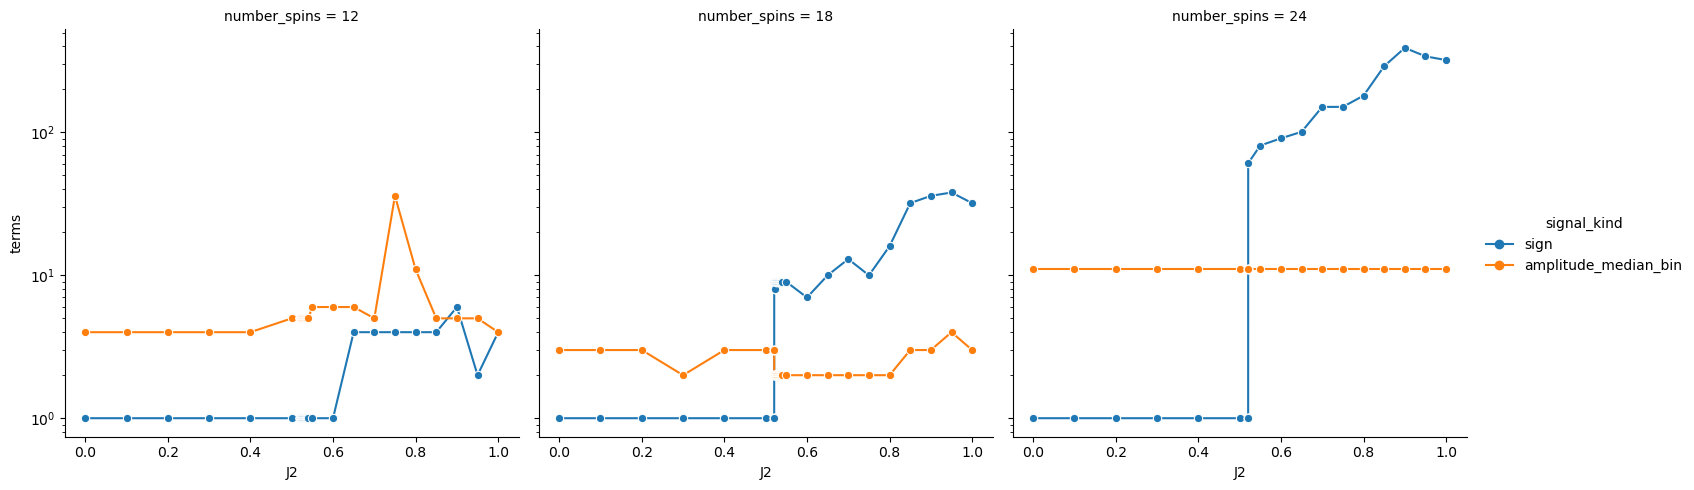

In [31]:
sns.relplot(
    analyzers_df,
    x="J2",
    y="terms",
    hue="signal_kind",
    col="number_spins",
    kind="line",
    # markers=True,
    style="signal_kind",
    dashes=False,
    markers=["o", "o"],
    # make y axis independent
    # facet_kws=dict(sharey=False),
).set(yscale="log")


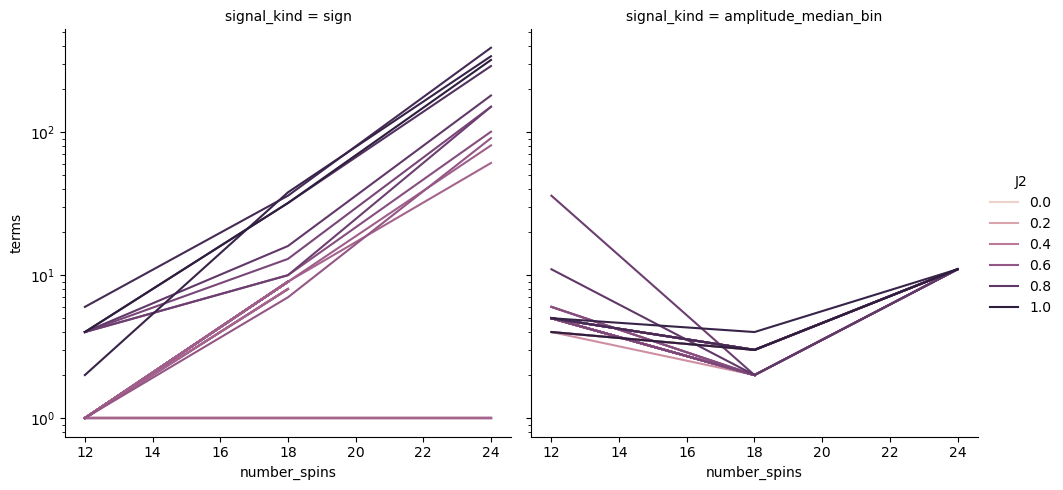

In [32]:
sns.relplot(
    analyzers_df.reset_index(),
    # .assign(J2=lambda df: df["J2"].astype(str)),
    x="number_spins",
    y="terms",
    col="signal_kind",
    hue="J2",
    kind="line",
    markers=True,
).set(yscale="log")


In [20]:
def plot_subsets(subsets, lat: SpinLattice):
    fig, axes = plt.subplots(1, len(subsets), figsize=(len(subsets) * 3, 3), squeeze=False)
    for ax, subset in zip(axes[0], subsets):
        lat.plot(spins=subset, ax=ax)
        ax.axis("off")
    return fig


In [42]:
analyzers_df

analyzer  ...    mean_hw
height J2     signal_kind                                                              ...           
2      0.0000 sign                  <boolean_analysis.BooleanFourierAnalyzer objec...  ...   4.000000
              amplitude_median_bin  <boolean_analysis.BooleanFourierAnalyzer objec...  ...   3.500000
       0.8000 sign                  <boolean_analysis.BooleanFourierAnalyzer objec...  ...   5.500000
              amplitude_median_bin  <boolean_analysis.BooleanFourierAnalyzer objec...  ...   3.090909
       0.3000 sign                  <boolean_analysis.BooleanFourierAnalyzer objec...  ...   4.000000
...                                                                               ...  ...        ...
4      0.5205 sign                  <boolean_analysis.BooleanFourierAnalyzer objec...  ...   8.000000
              amplitude_median_bin  <boolean_analysis.BooleanFourierAnalyzer objec...  ...   2.545455
       0.5206 sign                  <boolean_analysis.BooleanFourierAnalyzer objec...  ...   8.000000
              amplitude_median_bin  <boolean_analysis.BooleanFourierAnalyzer objec...  ...   2.545455
       0.5207 sign                  <boolean_analysis.BooleanFourierAnalyzer objec...  ...  11.508197

[231 rows x 7 columns]

In [48]:
analyzers_df.loc[4, 0.5207, "sign"]

analyzer          <boolean_analysis.BooleanFourierAnalyzer objec...
terms                                                            61
accuracy                                                   0.753656
sign_overlap                                                0.95295
hamming_weight                                                  702
number_spins                                                     24
mean_hw                                                   11.508197
Name: (4, 0.5207, sign), dtype: object

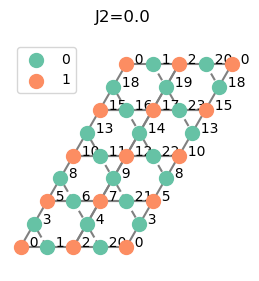

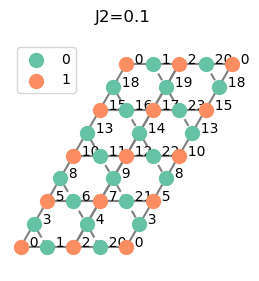

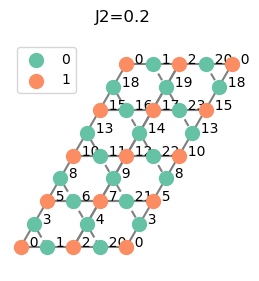

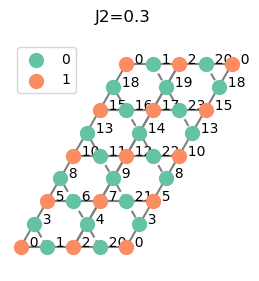

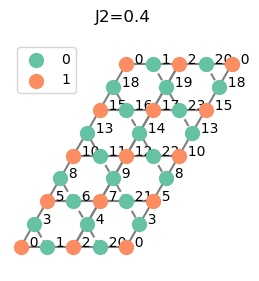

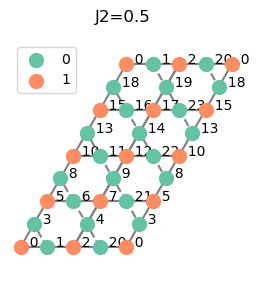

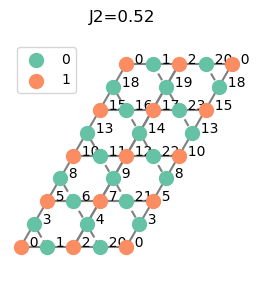

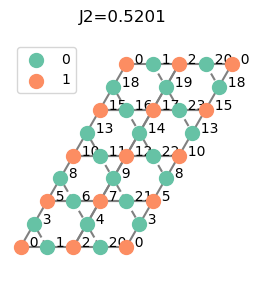

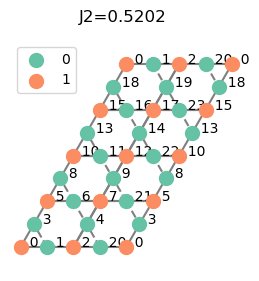

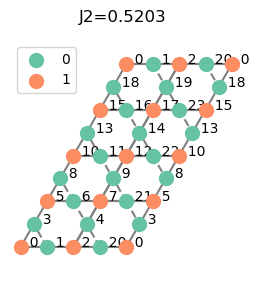

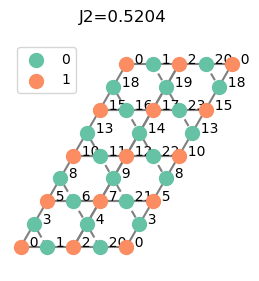

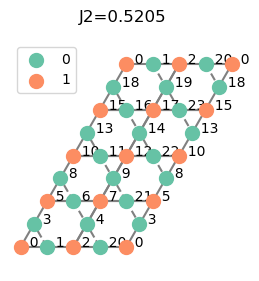

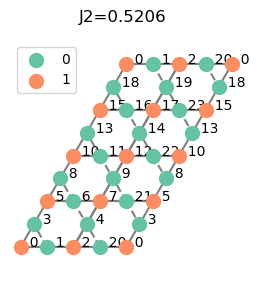

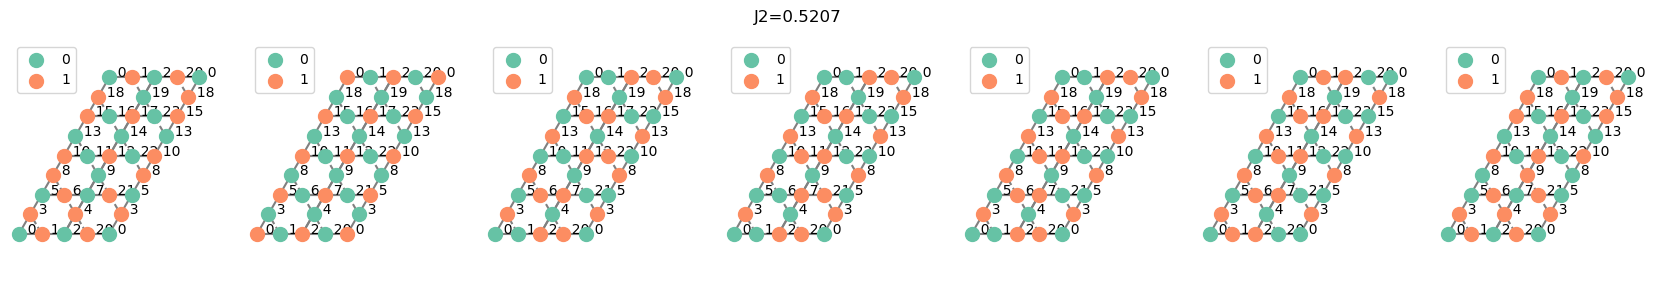

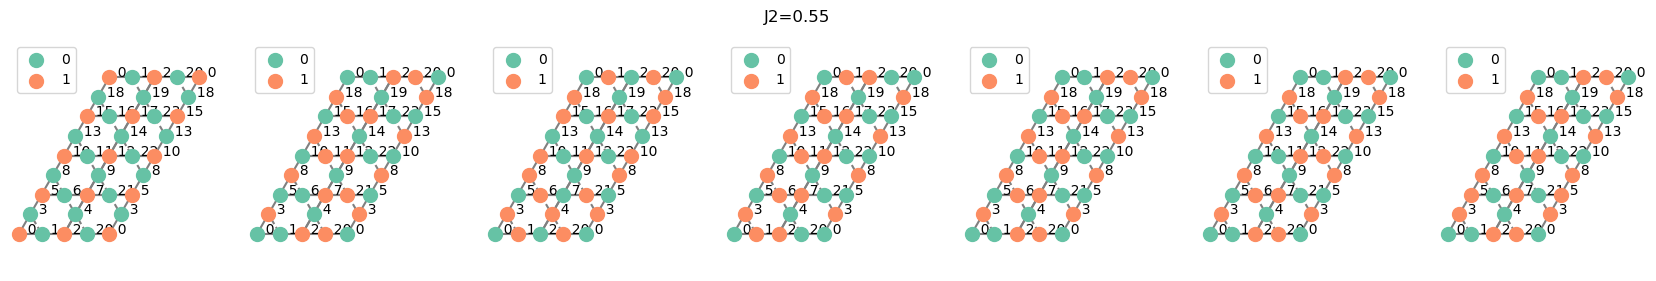

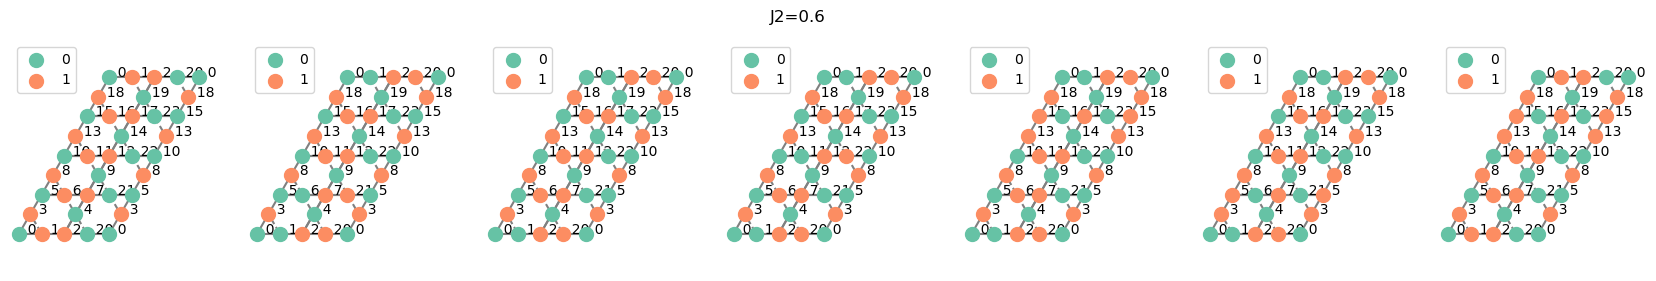

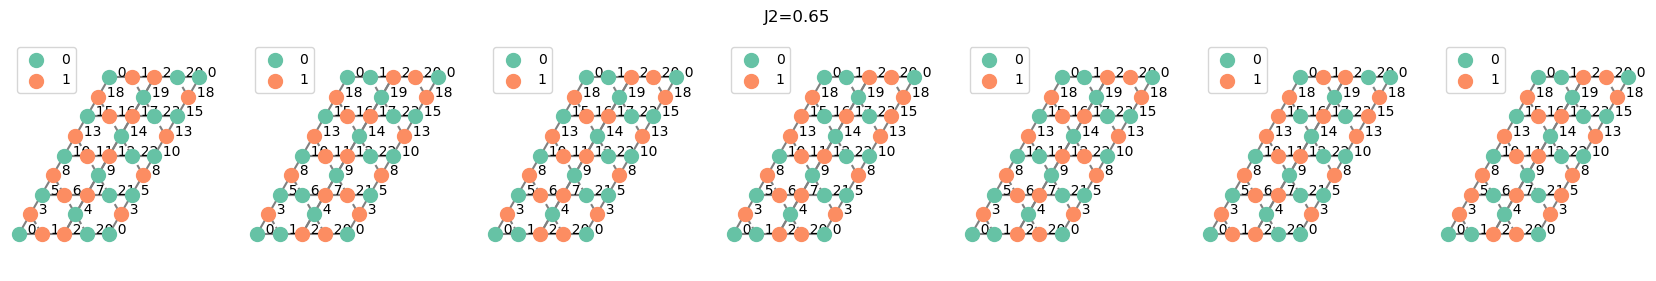

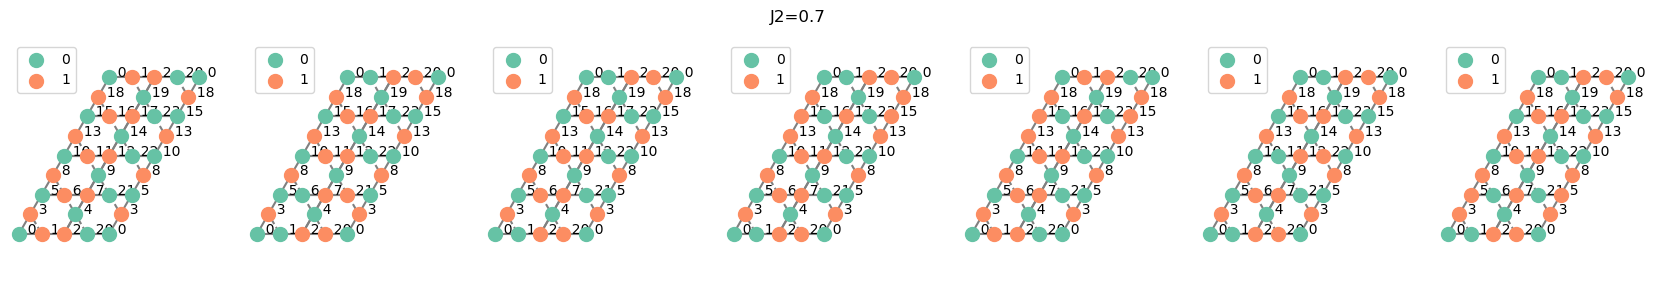

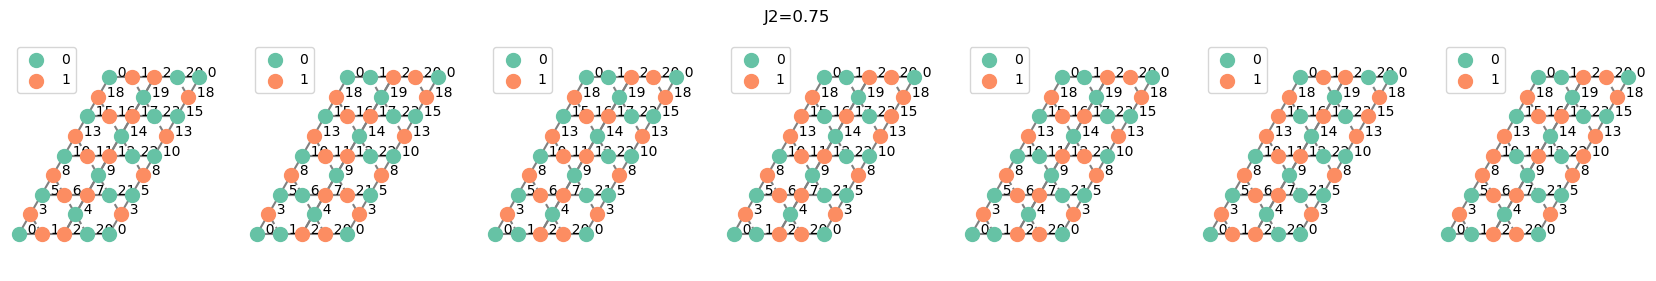

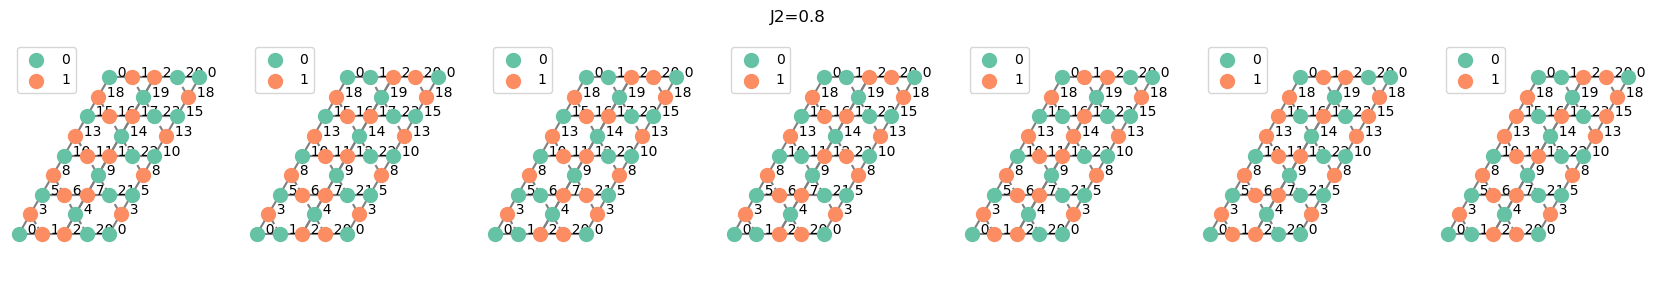

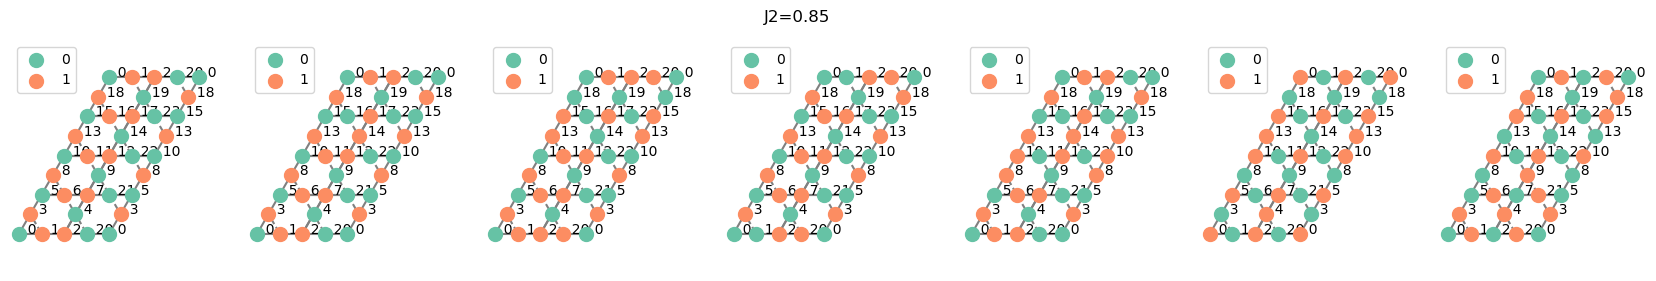

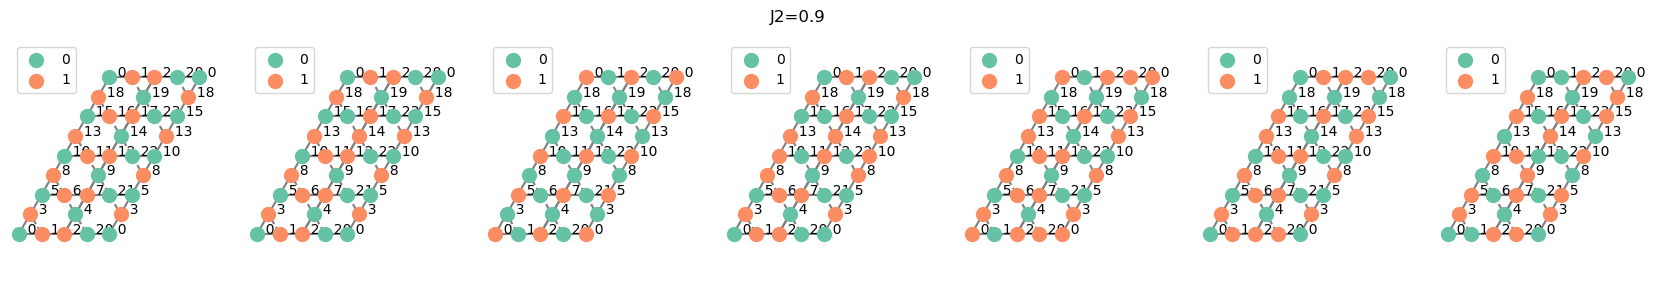

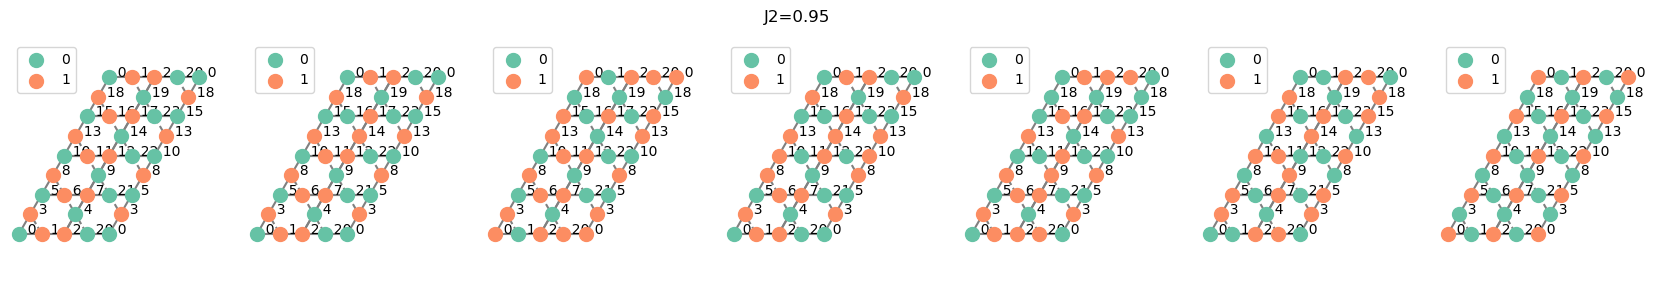

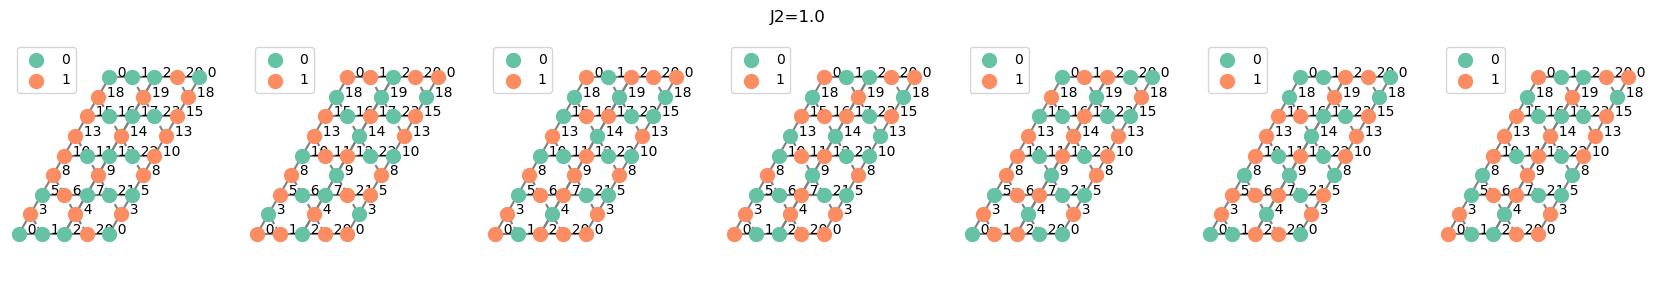

In [33]:
height = 4
# signal = "amplitude_median_bin"
max_subsets = 7
signal = "sign"
for J2, subsets in (
    analyzers_df.sort_index(level="J2")
    .xs((height, signal), level=("height", "signal_kind"))
    .assign(
        subsets=lambda df: [
            list(row["analyzer"].learner.get_coeffs_ser().iloc[: row["terms"]].index)
            for _, row in df.iterrows()
        ],
    )["subsets"]
    .items()
):
    plot_subsets(subsets[:max_subsets], KagomeLattice(width=2, height=height))
    plt.suptitle(f"J2={J2}")
    plt.show()


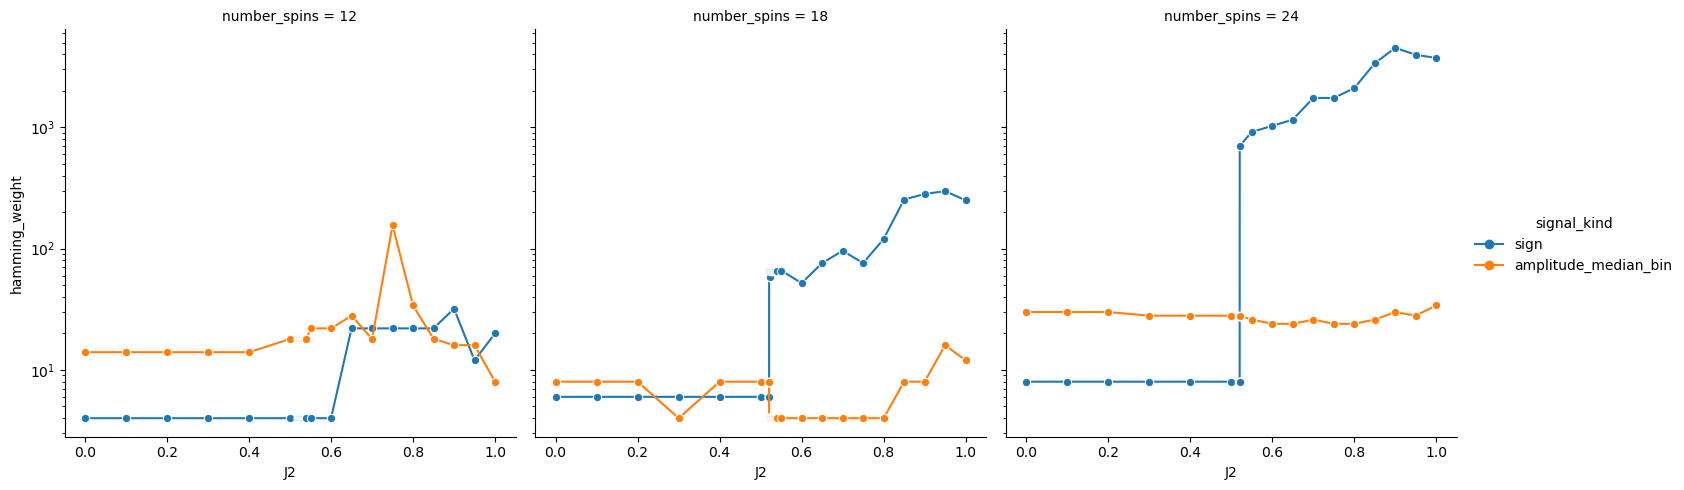

In [34]:
sns.relplot(
    analyzers_df,
    x="J2",
    y="hamming_weight",
    hue="signal_kind",
    col="number_spins",
    kind="line",
    style="signal_kind",
    dashes=False,
    facet_kws=dict(sharex=True),
    markers=["o", "o"],
).set(yscale="log")


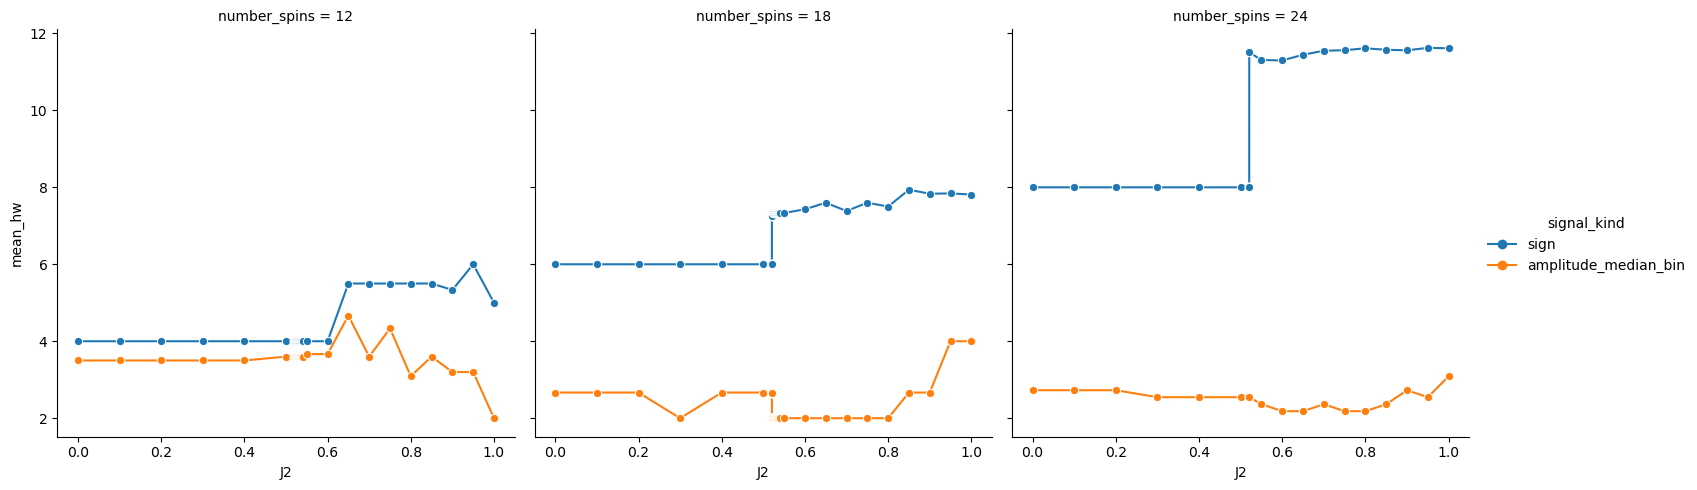

In [35]:
sns.relplot(
    analyzers_df,
    x="J2",
    y="mean_hw",
    hue="signal_kind",
    col="number_spins",
    kind="line",
    dashes=False,
    style="signal_kind",
    markers=["o", "o"],
)


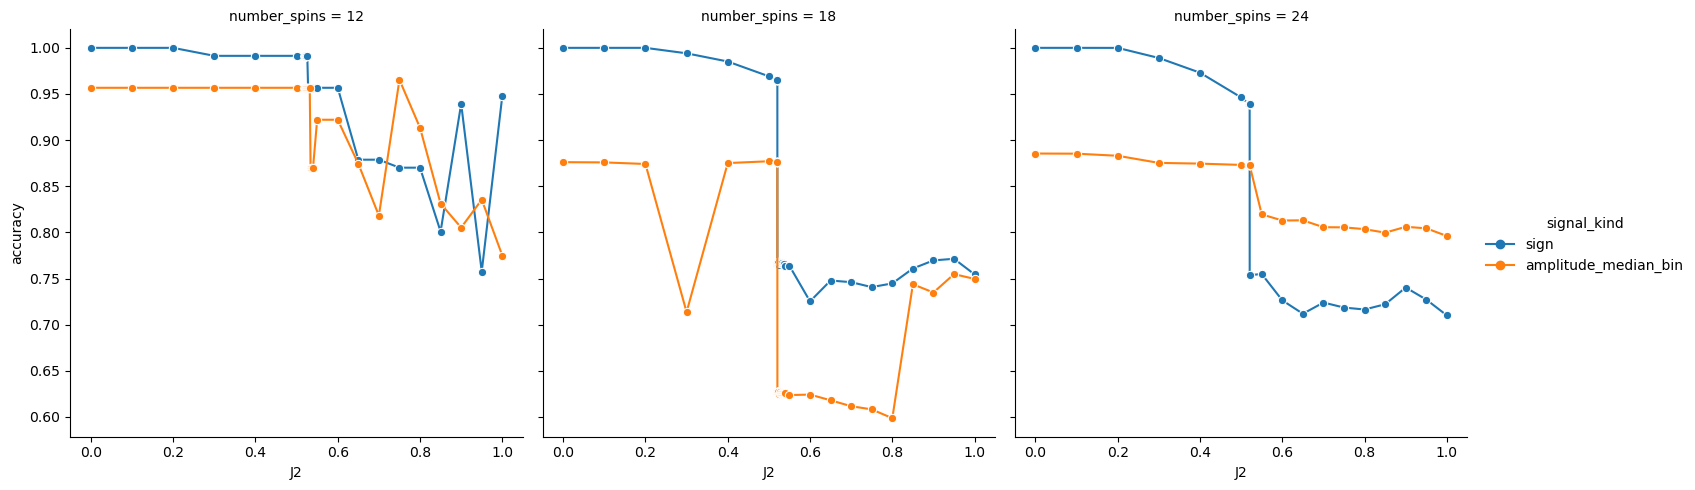

In [37]:
sns.relplot(
    analyzers_df,
    x="J2",
    y="accuracy",
    hue="signal_kind",
    col="number_spins",
    kind="line",
    dashes=False,
    style="signal_kind",
    markers=["o", "o"],
)


In [38]:
complexity_ratio_df = (
    analyzers_df.unstack(level="signal_kind")["hamming_weight"]
    .assign(ratio=lambda df: df["sign"] / df["amplitude_median_bin"])
    .reset_index()
)


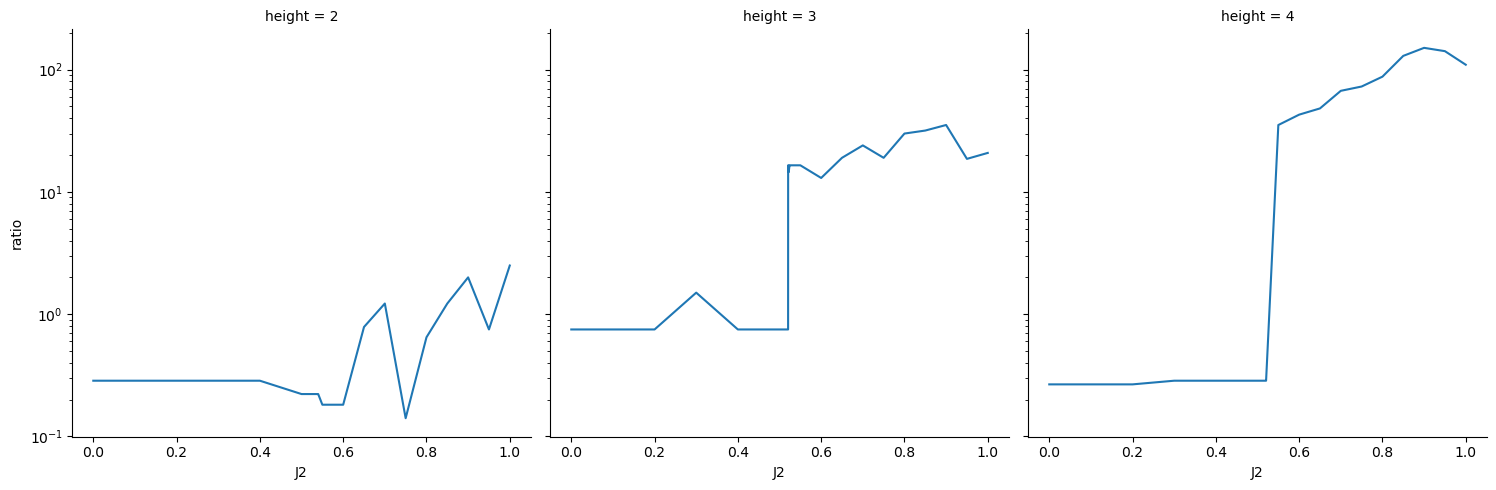

In [39]:
sns.relplot(complexity_ratio_df, x="J2", y="ratio", col="height", kind="line").set(yscale="log")


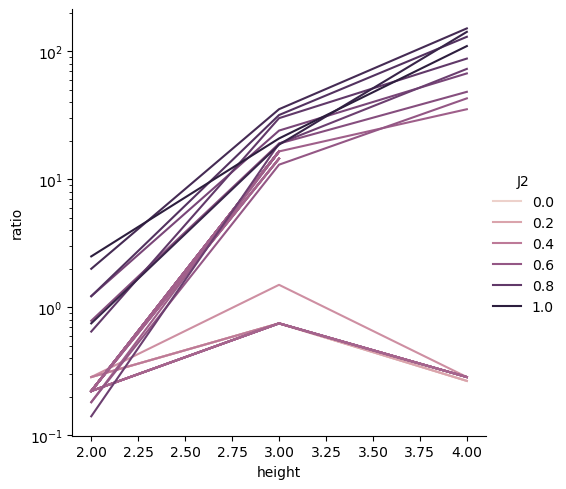

In [40]:
sns.relplot(
    complexity_ratio_df,
    x="height",
    y="ratio",
    hue="J2",
    kind="line",
).set(yscale="log")
